In [1]:
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import h5py
import scipy.sparse as sp
import time
import gget
from scipy.stats import spearmanr
from scipy.stats import pearsonr
from scipy.stats import ttest_ind
from tqdm import tqdm
import textwrap

import matplotlib.cm as cm
import matplotlib.colors as mcolors
from matplotlib.patches import Patch

import anndata as an
import scanpy as sc
import rapids_singlecell as rsc
import scvi

from scvi.external import CellAssign

import cupy as cp
import cuml

sc.settings.verbosity = 3

/nfs/turbo/umms-indikar/Cooper/conda_envs/rapids/lib/python3.12/site-packages/docrep/decorators.py:43: SyntaxWarning: 'param_categorical_covariate_keys' is not a valid key!
  doc = func(self, args[0].__doc__, *args[1:], **kwargs)
/nfs/turbo/umms-indikar/Cooper/conda_envs/rapids/lib/python3.12/site-packages/docrep/decorators.py:43: SyntaxWarning: 'param_continuous_covariate_keys' is not a valid key!
  doc = func(self, args[0].__doc__, *args[1:], **kwargs)


# Load anndata

In [2]:
%%time
fpath = "/nfs/turbo/umms-indikar/shared/projects/HSC/pipeline_outputs/integrated_anndata/pseudotime.h5ad"
adata = sc.read_h5ad(fpath)
adata

CPU times: user 372 ms, sys: 2.05 s, total: 2.42 s
Wall time: 8.09 s


AnnData object with n_obs × n_vars = 15867 × 21412
    obs: 'batch', 'phase', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'n_counts', 'n_genes', 'n_reads', 'raw_clusters', 'bbknn_clusters', 'harmony_clusters', 'cluster_str', 'barcoded_phase', 'S_score', 'G2M_score', 'dpt_pseudotime', 'dpt_groups', 'dpt_order', 'dpt_order_indices', 'G1_pseudotime', 'G1_order', 'G2M_pseudotime', 'G2M_order', 'mean_pseudotime', 'mean_order', 'nnz'
    var: 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_counts', 'highly_variable', 'means', 'dispersions', 'dispersio

# Load Capybara scores

In [3]:
%%time
# Load Capybara output
fpath_scale = "/nfs/turbo/umms-indikar/shared/projects/HSC/pipeline_outputs/integrated_anndata/capybara/hand_select_scale.csv"
df = pd.read_csv(fpath_scale)
print(f"{df.shape=}")
df.head()

df.shape=(15867, 14)
CPU times: user 28.7 ms, sys: 6.85 ms, total: 35.5 ms
Wall time: 45.3 ms


,cell_name,frxn_common myeloid progenitor,frxn_early lymphoid progenitor,frxn_embryonic fibroblast,frxn_endothelial cell of artery,frxn_endothelial cell of lymphatic vessel,frxn_granulocyte monocyte progenitor cell,frxn_hematopoietic multipotent progenitor cell,frxn_hematopoietic stem cell,frxn_megakaryocyte-erythroid progenitor cell,frxn_skin fibroblast,frxn_vein endothelial cell,Lagrangian,Error
0,AAACCCAAGGTTACCT-1,1.064789e-01,0.000000e+00,0.295457,1.818359e-02,0.225342,-5.646158e-18,-2.406669e-18,6.510849e-02,2.468684e-18,0.061838,-1.904588e-18,0,2195.172035
1,AAACCCAAGTTGAAGT-1,1.231129e-18,-3.642222e-18,0.284474,-3.358813e-19,0.280589,-9.676278e-18,-2.340368e-18,1.427924e-01,-7.659949e-20,0.000000,-1.235750e-17,0,2286.288671
2,AAACCCAAGTTGTCGT-1,2.287932e-01,0.000000e+00,0.331746,4.989489e-02,0.057511,7.570210e-03,-3.299127e-18,-1.613869e-19,2.896140e-17,0.082658,-2.775558e-17,0,2223.956211
3,AAACCCACAGAAGCGT-1,9.572310e-02,-1.443303e-20,0.316320,-9.333794e-19,0.170448,-2.259382e-18,-1.118235e-18,0.000000e+00,-5.200967e-17,0.162131,2.660199e-18,0,2230.398963
4,AAACCCACAGGAGGTT-1,1.355386e-01,7.281186e-19,0.268942,1.715131e-01,0.152521,4.918820e-18,-9.131573e-19,0.000000e+00,7.416660e-18,0.054936,1.316851e-17,0,2064.401601


In [4]:
# Set index to 'cell_name' for merging
df = df.set_index('cell_name')

# Sanity check: ensure all indices in df exist in adata.obs
common_cells = adata.obs.index.intersection(df.index)
print(f"Merging on {len(common_cells)} shared cells")

# Merge into adata.obs
adata.obs = adata.obs.join(df, how='left')  # 'left' keeps all cells in adata.obs

adata.obs.head()

Merging on 15867 shared cells


,batch,phase,n_genes_by_counts,log1p_n_genes_by_counts,total_counts,log1p_total_counts,pct_counts_in_top_50_genes,pct_counts_in_top_100_genes,pct_counts_in_top_200_genes,pct_counts_in_top_500_genes,...,frxn_endothelial cell of artery,frxn_endothelial cell of lymphatic vessel,frxn_granulocyte monocyte progenitor cell,frxn_hematopoietic multipotent progenitor cell,frxn_hematopoietic stem cell,frxn_megakaryocyte-erythroid progenitor cell,frxn_skin fibroblast,frxn_vein endothelial cell,Lagrangian,Error
AAACCCAAGGTTACCT-1,hsc,G1,3679,8.210668,11202.0,9.323937,27.932512,37.752187,47.491519,60.382075,...,1.818359e-02,0.225342,-5.646158e-18,-2.406669e-18,6.510849e-02,2.468684e-18,0.061838,-1.904588e-18,0,2195.172035
AAACCCAAGTTGAAGT-1,hsc,G1,3987,8.291045,10579.0,9.266721,24.766046,32.867001,40.835618,53.313168,...,-3.358813e-19,0.280589,-9.676278e-18,-2.340368e-18,1.427924e-01,-7.659949e-20,0.000000,-1.235750e-17,0,2286.288671
AAACCCAAGTTGTCGT-1,hsc,S,2585,7.857868,6735.0,8.815222,28.537491,37.371938,48.136600,63.533779,...,4.989489e-02,0.057511,7.570210e-03,-3.299127e-18,-1.613869e-19,2.896140e-17,0.082658,-2.775558e-17,0,2223.956211
AAACCCACAGAAGCGT-1,hsc,G1,2358,7.765993,5416.0,8.597297,24.686115,34.785820,45.217873,60.672083,...,-9.333794e-19,0.170448,-2.259382e-18,-1.118235e-18,0.000000e+00,-5.200967e-17,0.162131,2.660199e-18,0,2230.398963
AAACCCACAGGAGGTT-1,hsc,G1,4997,8.516793,21937.0,9.995976,31.845740,40.552491,50.152710,63.440762,...,1.715131e-01,0.152521,4.918820e-18,-9.131573e-19,0.000000e+00,7.416660e-18,0.054936,1.316851e-17,0,2064.401601


# Predictions by Cluster

frxn_common myeloid progenitor
frxn_early lymphoid progenitor
frxn_embryonic fibroblast
frxn_endothelial cell of artery
frxn_endothelial cell of lymphatic vessel
frxn_granulocyte monocyte progenitor cell
frxn_hematopoietic multipotent progenitor cell
frxn_hematopoietic stem cell
frxn_megakaryocyte-erythroid progenitor cell
frxn_skin fibroblast
frxn_vein endothelial cell


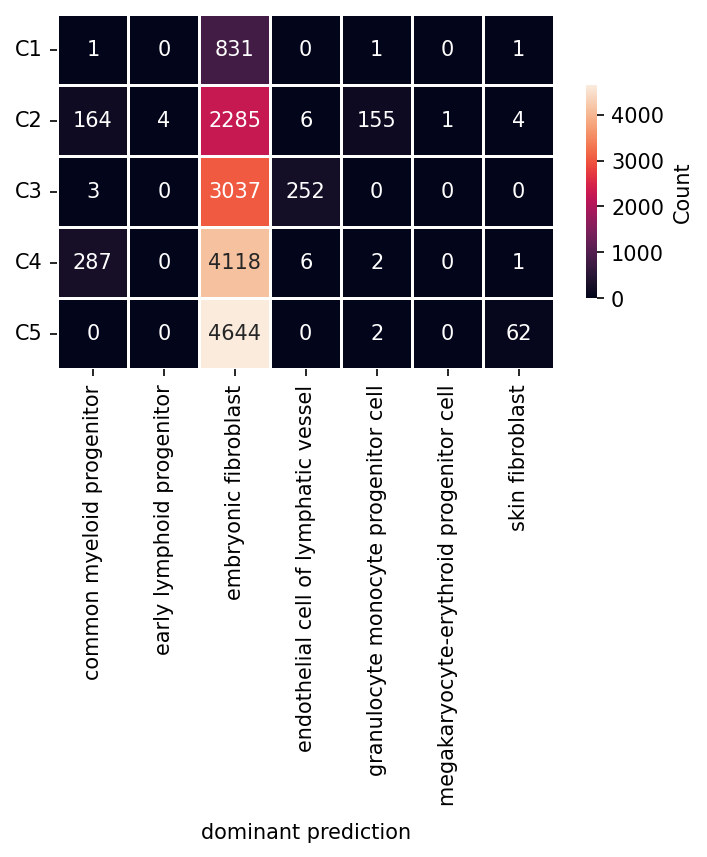

In [5]:
df = adata.obs.copy()
frxn_cols = [col for col in df.columns if col.startswith("frxn_")]

for x in frxn_cols:
    print(x)

df['prediction'] = df[frxn_cols].idxmax(axis=1)
df['prediction'] = df['prediction'].apply(lambda x: x.replace("frxn_", ""))

X = pd.crosstab(df['cluster_str'], df['prediction'])

plt.rcParams['figure.dpi'] = 150
plt.rcParams['figure.figsize'] = 5, 5

ax = sns.heatmap(
    X,
    annot=True,
    fmt="d",
    linewidths=0.5,
    square=True,
    cbar_kws={"label": "Count", 'shrink' : 0.6},
)

ax.set_xlabel("dominant prediction", labelpad=8)
ax.set_ylabel("")
ax.tick_params(axis='y', rotation=0)
plt.tight_layout()
plt.show()


frxn_common myeloid progenitor
frxn_early lymphoid progenitor
frxn_embryonic fibroblast
frxn_endothelial cell of artery
frxn_endothelial cell of lymphatic vessel
frxn_granulocyte monocyte progenitor cell
frxn_hematopoietic multipotent progenitor cell
frxn_hematopoietic stem cell
frxn_megakaryocyte-erythroid progenitor cell
frxn_skin fibroblast
frxn_vein endothelial cell


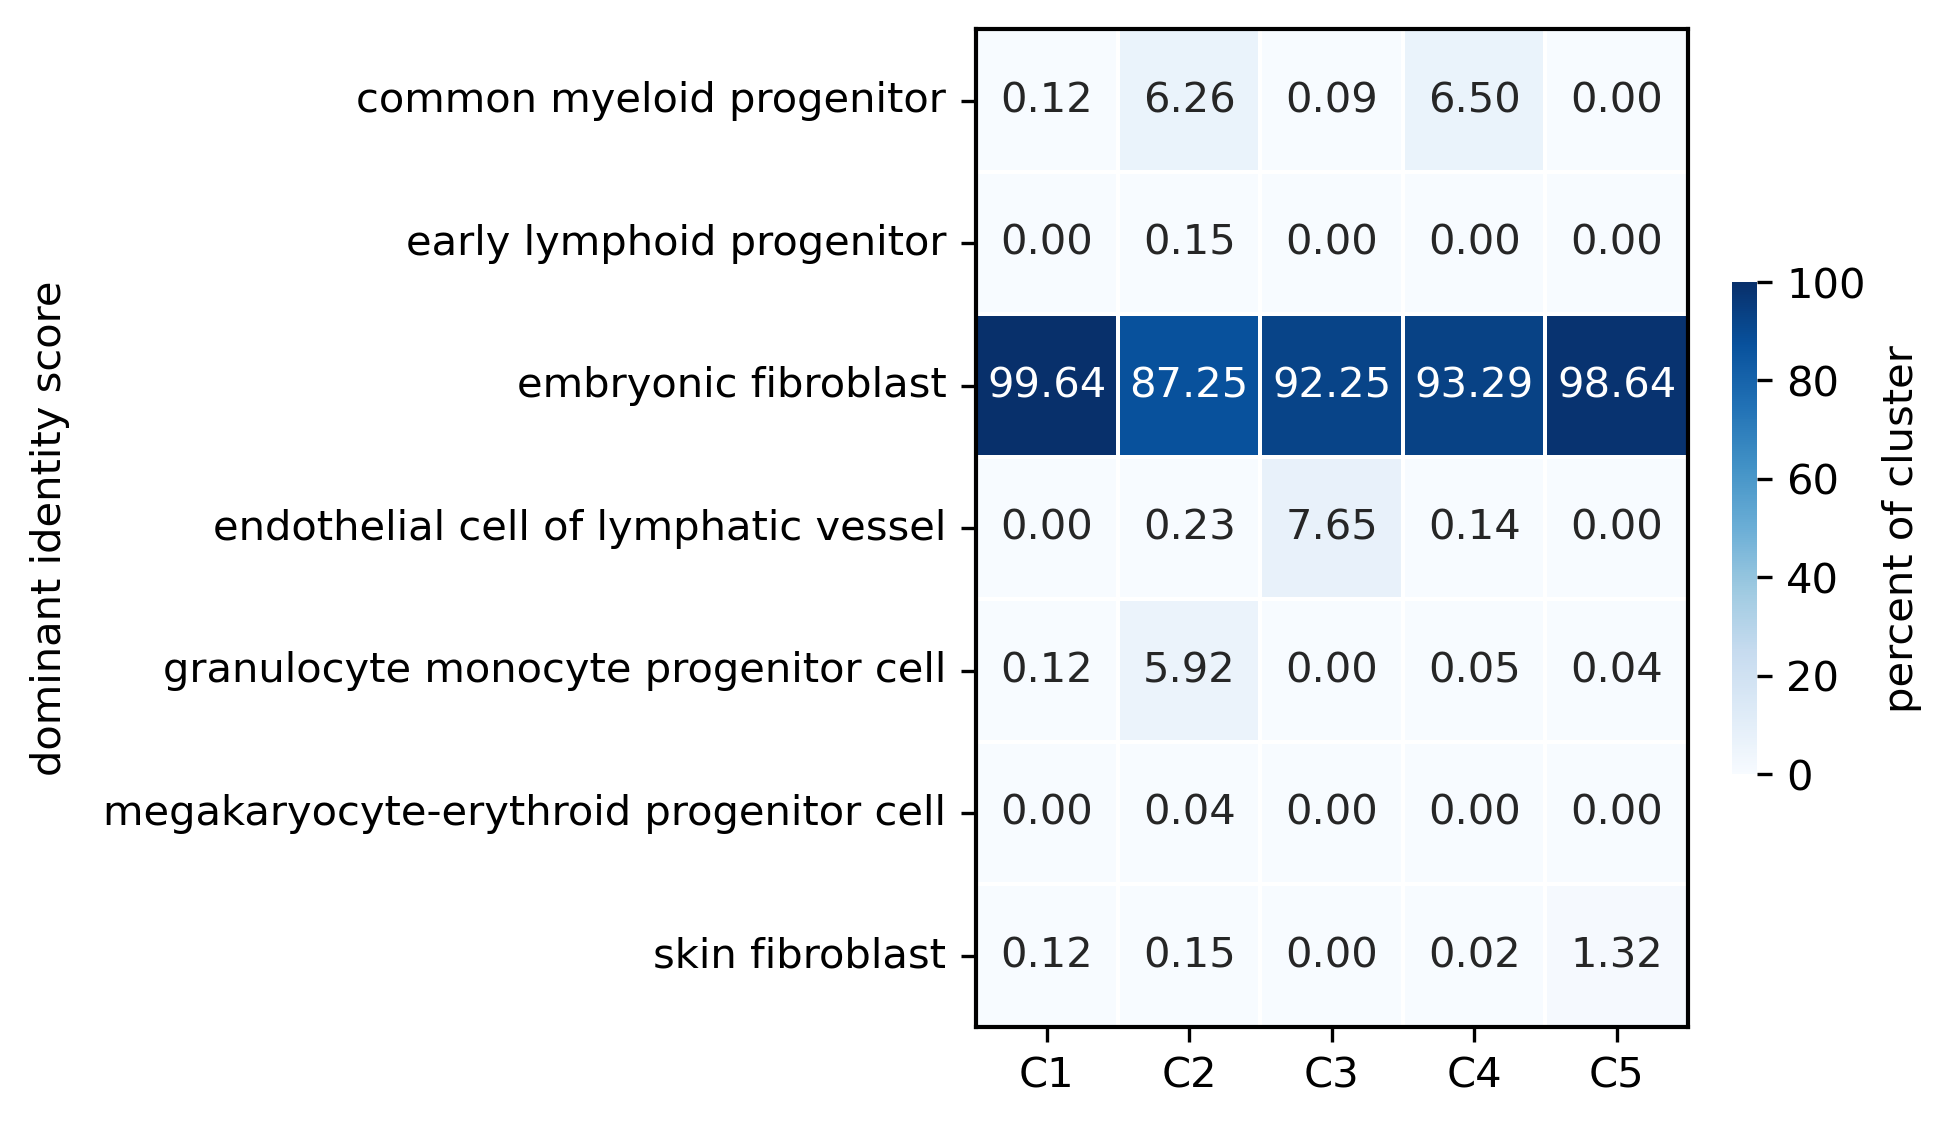

In [6]:
df = adata.obs.copy()
frxn_cols = [col for col in df.columns if col.startswith("frxn_")]

for x in frxn_cols:
    print(x)

df['prediction'] = df[frxn_cols].idxmax(axis=1)
df['prediction'] = df['prediction'].apply(lambda x: x.replace("frxn_", ""))

# Compute crosstab as before
X = pd.crosstab(df['cluster_str'], df['prediction'])

# Convert to row percentages
X_percent = X.div(X.sum(axis=1), axis=0)
X_percent = X_percent * 100

plt.rcParams['figure.dpi'] = 300
plt.rcParams['figure.figsize'] = 6, 6

ax = sns.heatmap(
    X_percent.T,
    annot=True,
    cmap='Blues',
    fmt=".2f",
    linewidths=0.5,
    # linecolor='k',
    square=True,
    cbar_kws={"label": "percent of cluster", 'shrink' : 0.3},
    vmin=0, vmax=100,
)

ax.set_ylabel("dominant identity score", labelpad=8)
ax.set_xlabel("")
ax.tick_params(axis='y', rotation=0)

# Add all spines (borders)
for _, spine in ax.spines.items():
    spine.set_visible(True)
    spine.set_linewidth(1)
    spine.set_edgecolor("black")

plt.tight_layout()
plt.show()

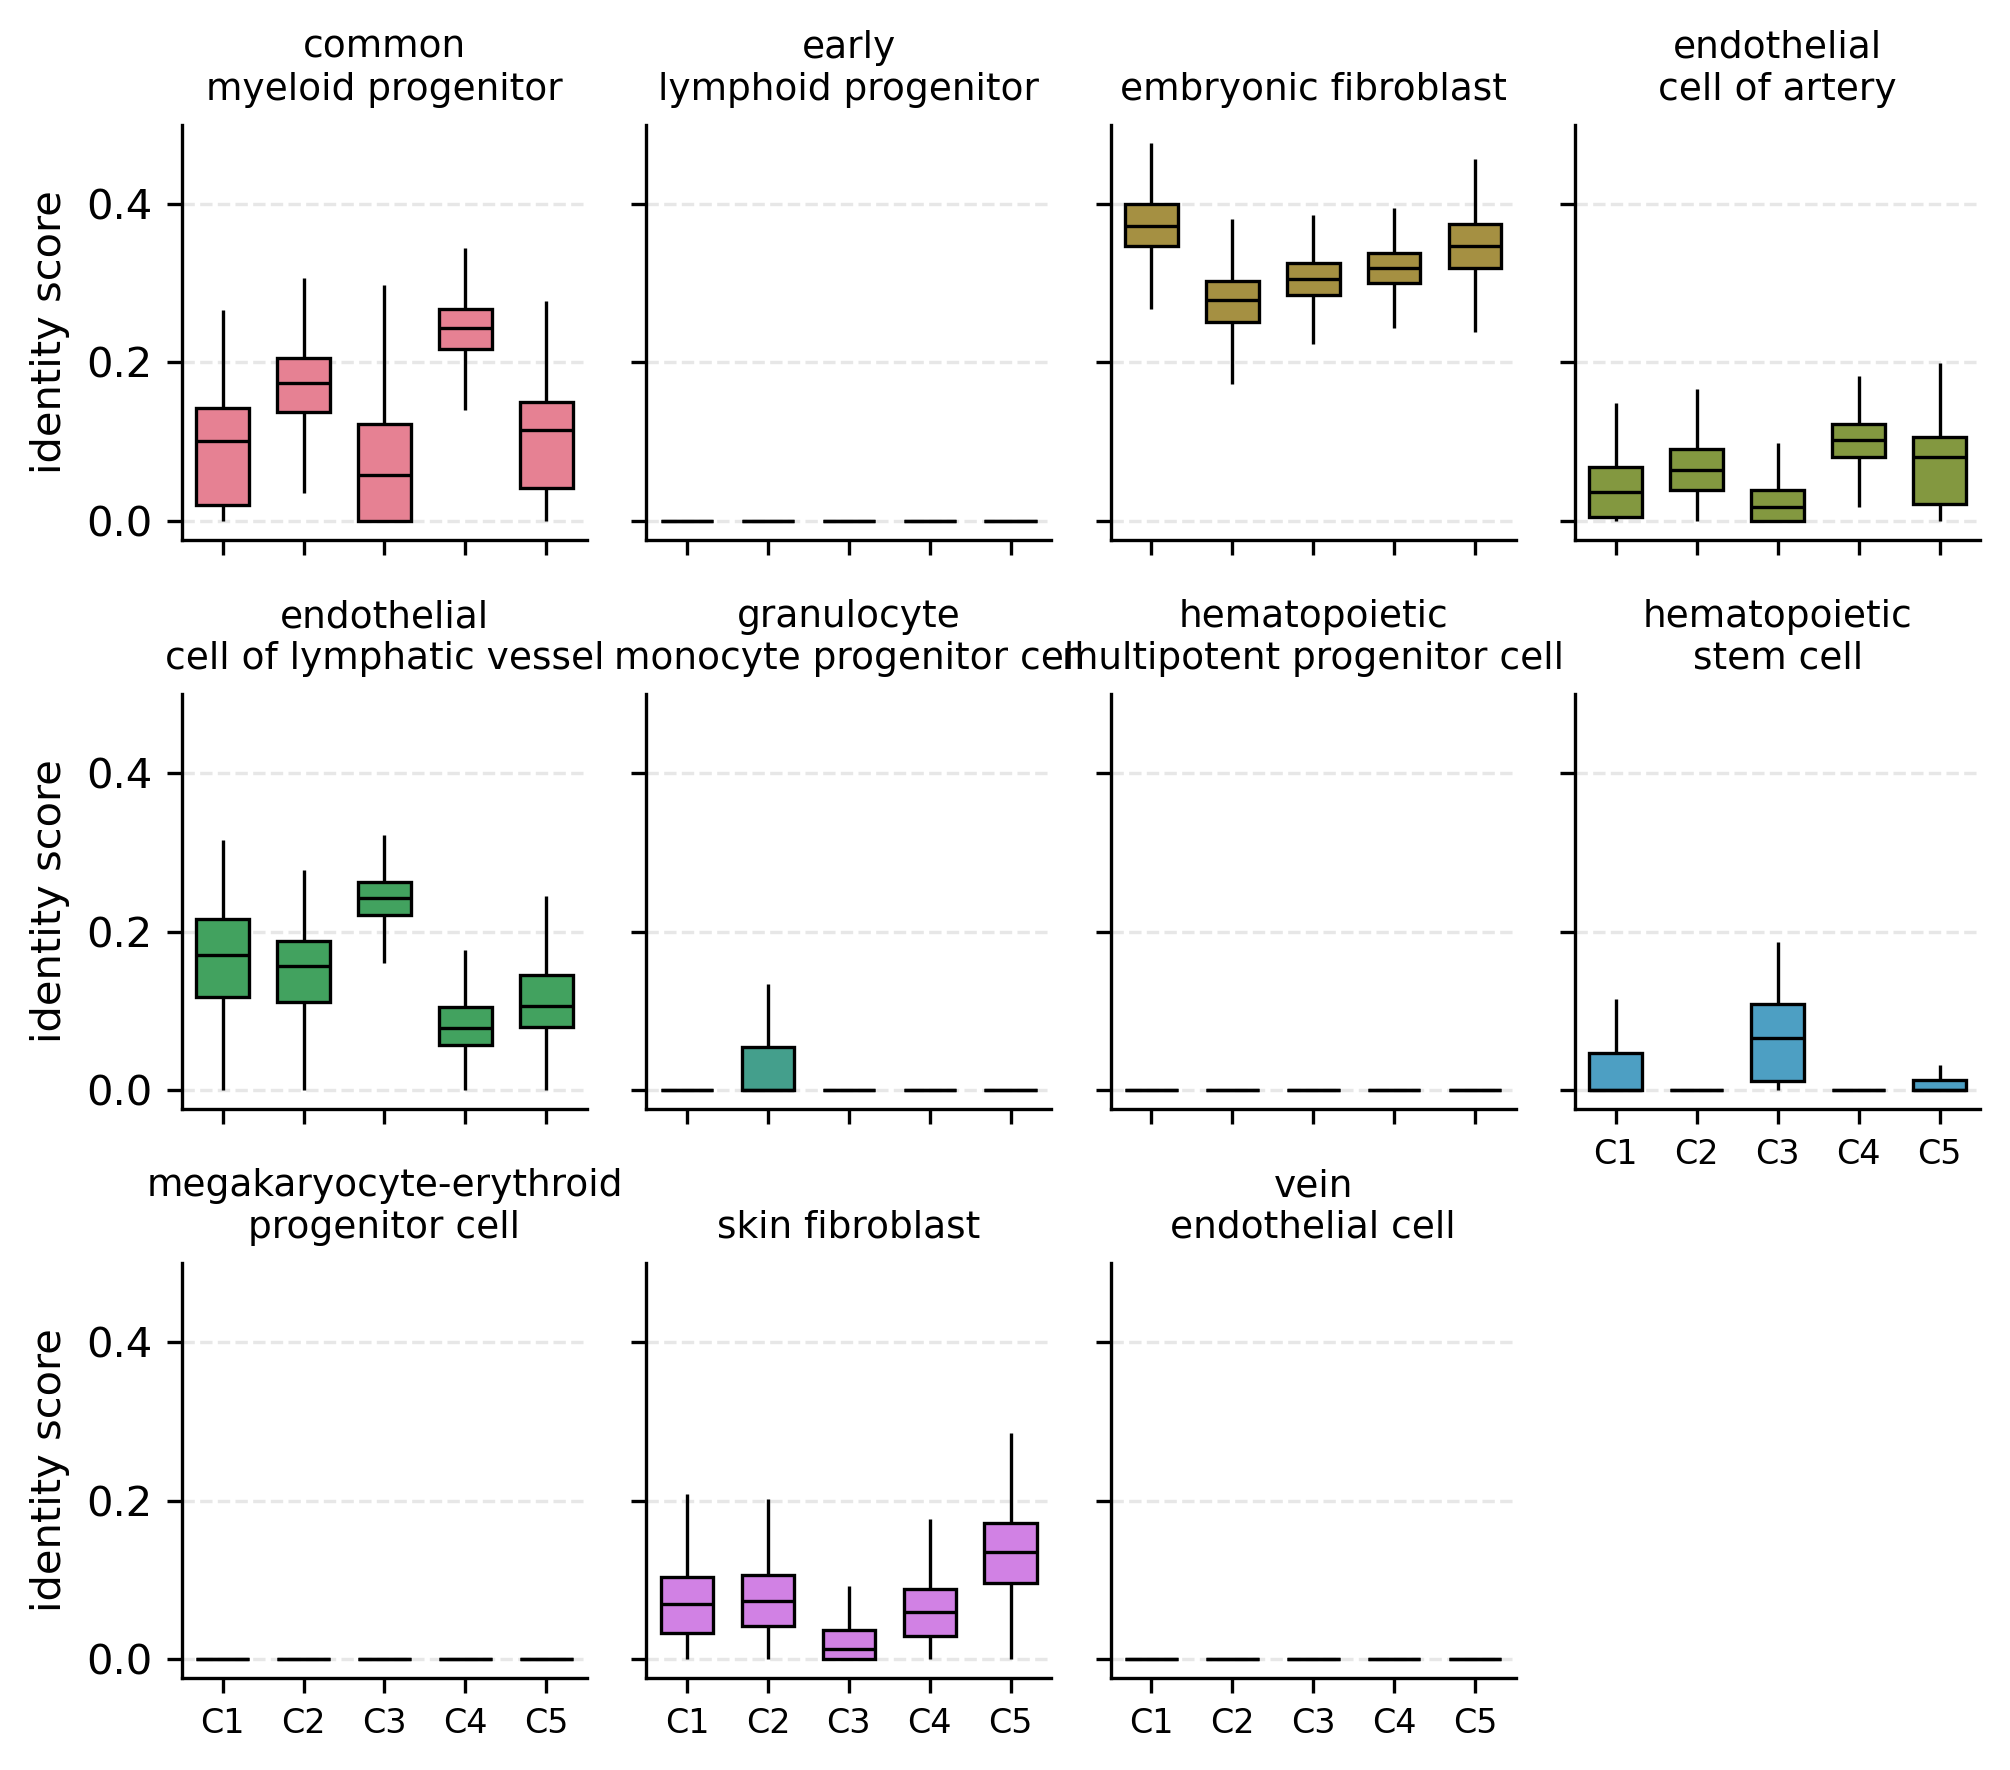

In [9]:
# Copy and melt
df = adata.obs.copy()
frxn_cols = [col for col in df.columns if col.startswith("frxn_")]
df_melted = df.melt(
    id_vars=["cluster_str"],
    value_vars=frxn_cols,
    var_name="Cell Type",
    value_name="Fraction"
)


# Plot with FacetGrid
g = sns.FacetGrid(
    df_melted,
    col="Cell Type",
    hue="Cell Type",
    col_wrap=4,
    sharey=True,
    height=2,
    aspect=0.85,
)

g.map_dataframe(
    sns.boxplot,
    x="cluster_str",
    y="Fraction",
    order=sorted(df["cluster_str"].unique()),
    width=0.65,
    linecolor='k',
    capprops={'linewidth': 0},  
    showfliers=False,
    linewidth=0.8
)

g.set_axis_labels("", "identity score")
for ax in g.axes.flat:
    ax.tick_params(axis='x', rotation=0, labelsize=8)
    ax.grid(axis='y', linestyle='--', alpha=0.3)
     
    title = ax.get_title()
    title = title.split("frxn_")[1]
    if len(title) > 20:
        title = "\n".join(title.split(maxsplit=1))
    ax.set_title(title, fontsize=9)

g.fig.subplots_adjust(wspace=0.2)

plt.tight_layout()
plt.show()


In [8]:
break

SyntaxError: 'break' outside loop (668683560.py, line 1)

In [ ]:
# # Select frxn columns
# df = adata.obs.copy()
# frxn_cols = [col for col in df.columns if col.startswith("frxn_")]
# print(frxn_cols)

# # Melt the data
# df_melted = df.melt(
#     id_vars=["cluster_str"],
#     value_vars=frxn_cols,
#     var_name="Cell Type",
#     value_name="Fraction"
# )

# # filter 
# keep = [
#     'frxn_embryonic fibroblast', 
#     'frxn_endothelial cell',
#     'frxn_fibro/adipogenic progenitor cell', 
#    ]
# df_melted = df_melted[df_melted["Cell Type"].isin(keep)]

# # Improve cell type labels (optional)
# df_melted["Cell Type"] = df_melted["Cell Type"].str.replace("frxn_", "").str.replace("_", " ")
# df_melted = df_melted.sort_values("Cell Type")


# # Plot
# plt.rcParams['figure.dpi'] = 300
# plt.rcParams['figure.figsize'] = 4, 3

# sns.boxplot(
#     data=df_melted,
#     x="cluster_str",
#     y="Fraction",
#     hue="Cell Type",
#     showfliers=False,
#     capprops={'lw':0,},
#     linecolor='k',
#     linewidth=0.8,
#     palette='nipy_spectral',
# )

# sns.stripplot(
#     data=df_melted[df_melted["Fraction"] > 0],
#     x="cluster_str",
#     y="Fraction",
#     hue="Cell Type",
#     dodge=True,
#     jitter=0.25,
#     alpha=0.5,
#     s=0.5,
#     edgecolor='none',
#     palette='dark:k',
#     legend=False,
# )

# plt.xlabel("")
# plt.ylabel("identity score")
# plt.xticks(rotation=0, fontsize=10)
# plt.yticks(fontsize=10)

# plt.grid(axis='y', linestyle='--', alpha=0.3)
# plt.margins(y=0.1)
# plt.legend(
#     title="", 
#     bbox_to_anchor=(1.75, 0.5), 
#     loc='center right',
#     fontsize=8,
#     markerscale=2.5
    
# )
# sns.despine()
# plt.show()


In [ ]:
plt.rcParams['figure.dpi'] = 300
plt.rcParams['figure.figsize'] = 4, 4

frxn_cols = [col for col in adata.obs.columns if col.startswith("frxn_")]
print(frxn_cols)

sc.pl.draw_graph(
    adata, 
    color=frxn_cols,
    size=15,
    ncols=3,
    alpha=1,
    use_raw=False,
    add_outline=True,
    outline_color=('k', 'k'),
    na_in_legend=False,
    cmap='gnuplot',
    frameon=False,
    wspace=0.15,
    show=False, 
)

In [ ]:
pdf = adata.obs.copy()

# Extract variables
x = pdf['mean_pseudotime']
y = pdf['frxn_endothelial cell']

# Compute Pearson correlation
r, p = pearsonr(x, y)
print(f"{r=} {p=}")

# Set figure parameters
plt.rcParams['figure.dpi'] = 300
plt.rcParams['figure.figsize'] = (3, 3)

# Create plot
ax = sns.regplot(
    data=pdf,
    x='mean_pseudotime',
    y='frxn_endothelial cell',
    x_bins=100,
    scatter_kws={'s': 5, 'alpha': 0.7, 'color': 'gray'},
    line_kws={'color': 'blue', 'linewidth': 1.5}
)

# Annotate plot
plt.title('endothelial score', fontsize=12)
plt.xlabel("pseudotime", fontsize=11)
plt.ylabel("proportion", fontsize=11)
plt.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)

# Add r and p-value annotation
annot_text = f"$r$ = {r:.2f}"
ax.text(0.05, 0.95, annot_text, transform=ax.transAxes,
        fontsize=10, verticalalignment='top', bbox=dict(facecolor='white', edgecolor='gray', boxstyle='round,pad=0.3'))

sns.despine()
plt.tight_layout()
plt.show()


# Error 

In [ ]:
plt.rcParams['figure.dpi'] = 150
plt.rcParams['figure.figsize'] = 3, 3

sns.boxplot(
    data=adata.obs,
    x='cluster_str',
    y='Error',
    hue='cluster_str',
    showfliers=False,
    capprops={'lw':0,},
    linecolor='k',
    linewidth=0.8,
)

plt.xlabel("")
sns.despine()

print(adata.obs.groupby('cluster_str').agg(
    mean_error = ('Error', 'mean'),
    std_error = ('Error', 'std'),
    
).to_string())

In [ ]:
# Select frxn columns
df = adata.obs.copy()
frxn_cols = [col for col in df.columns if col.startswith("frxn_")]
print(frxn_cols)

# Melt the data
df_melted = df.melt(
    id_vars=["cluster_str"],
    value_vars=frxn_cols,
    var_name="Cell Type",
    value_name="Fraction"
)

# Improve cell type labels (optional)
df_melted["Cell Type"] = df_melted["Cell Type"].str.replace("frxn_", "").str.replace("_", " ").str.title()
df_melted = df_melted.sort_values("Cell Type")


# Plot
plt.rcParams['figure.dpi'] = 300
plt.rcParams['figure.figsize'] = 15, 3
sns.boxplot(
    data=df_melted,
    x="cluster_str",
    y="Fraction",
    hue="Cell Type",
    showfliers=False,
    capprops={'lw':0,},
    linecolor='k',
    linewidth=0.8,
    palette='tab20',
)

plt.xlabel("", fontsize=12)
plt.ylabel("proportion", fontsize=12)
plt.xticks(rotation=0, fontsize=10)
plt.yticks(fontsize=10)
plt.legend(title="Cell Type", bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9, title_fontsize=10, ncols=3)
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
sns.despine()
plt.show()


In [ ]:
# break

In [ ]:
# Copy and melt
df = adata.obs.copy()
frxn_cols = [col for col in df.columns if col.startswith("frxn_")]
df_melted = df.melt(
    id_vars=["cluster_str"],
    value_vars=frxn_cols,
    var_name="Cell Type",
    value_name="Fraction"
)


# Plot with FacetGrid
g = sns.FacetGrid(
    df_melted,
    col="Cell Type",
    col_wrap=3,
    sharey=True,
    height=2,
    aspect=0.9,
)

g.map_dataframe(
    sns.boxplot,
    x="cluster_str",
    y="Fraction",
    hue='Cell Type',
    order=sorted(df["cluster_str"].unique()),
    width=0.45,
    linecolor='k',
    capprops={'linewidth': 0},  
    # flierprops={'markersize': 0.5, 'alpha': 0.5},
    showfliers=False,
    linewidth=0.8
)

g.set_axis_labels("", "identity score")
for ax in g.axes.flat:
    ax.tick_params(axis='x', rotation=0, labelsize=8)
    ax.grid(axis='y', linestyle='--', alpha=0.3)
     
    title = ax.get_title()
    title = title.split("frxn_")[1]
    ax.set_title(title, fontsize=6)

g.fig.subplots_adjust(wspace=0.2)

plt.tight_layout()
sns.despine(trim=True)
plt.show()


In [ ]:
break

# Discrete assignment

In [ ]:
# Assign based on max fraction
frac_cols = ['frxn_endothelial_cells', 'frxn_fibroblasts', 
             'frxn_hematopoietic_progenitors', 'frxn_hsc']
adata.obs['capybara_assignment'] = adata.obs[frac_cols].idxmax(axis=1)

print(adata.obs['capybara_assignment'].value_counts().to_string())
print()

# Group and count
plot_df = (
    adata.obs
    .groupby(['cluster_str', 'capybara_assignment'])
    .size()
    .reset_index(name='count')
)

# Clean labels
plot_df['capybara_assignment'] = (
    plot_df['capybara_assignment']
    .str.replace("frxn_", "", regex=False)
    .str.replace("_", " ")
)

# Normalize to proportions within each cluster
plot_df['proportion'] = (
    plot_df
    .groupby('cluster_str')['count']
    .transform(lambda x: x / x.sum())
)
plot_df.head()

In [ ]:
color_dict = {
    'endothelial cells':  "#1F78B4",
    'fibroblasts':        "#1B9E77",  
    'hematopoietic progenitors':  "#6A3D9A",  
}

plt.rcParams['figure.dpi'] = 300
plt.rcParams['figure.figsize'] = 4, 2

sns.barplot(
    data=plot_df,
    x='cluster_str',
    y='proportion',
    hue='capybara_assignment',
    palette=color_dict,
    ec='k',
)

sns.move_legend(
    plt.gca(), 
    title="",
    loc='lower center',
    ncols=3,
    frameon=False,
    bbox_to_anchor=(0.5, -0.35),
    fontsize=7,
)

plt.ylabel('proportion of cluster')

sns.despine()
plt.xlabel("")

In [ ]:
assignments = sorted(plot_df['capybara_assignment'].unique())

color_dict = {
    'endothelial cells':  "#1F78B4",
    'fibroblasts':        "#1B9E77",  
    'hematopoietic progenitors':  "#6A3D9A",  
}

# Prepare base figure
clusters = sorted(plot_df['cluster_str'].unique())
n = len(clusters)

plt.rcParams['figure.dpi'] = 300
plt.rcParams['figure.figsize'] = 1.5 * n, 2  # Wider per pie
fig, ax = plt.subplots()

# Draw each pie at x=i
for i, cluster in enumerate(clusters):
    sub_df = plot_df[plot_df['cluster_str'] == cluster]
    sizes = sub_df['proportion']
    colors = [color_dict[cell_type] for cell_type in sub_df['capybara_assignment']]
    labels = [f"{p*100:.0f}%" if p > 0.005 else "" for p in sizes]
    
    # Wider + closer pie charts: adjust x0, width, height
    x0 = i / n  # evenly spaced, no extra padding
    inset_ax = ax.inset_axes([x0, 0.05, 0.2, 0.9])  # narrower width
    inset_ax.pie(
        sizes,
        colors=colors,
        labels=labels,
        labeldistance=1.25,  # moves labels outside
        startangle=90,
        textprops={'fontsize': 7},
        wedgeprops={'linewidth': 1, 'edgecolor': 'k'}
    )
    inset_ax.set_aspect("equal")
    inset_ax.axis('off')

# Axis formatting
ax.set_xlim(-0.5, len(clusters))
ax.set_xticks(np.array(range(len(clusters))) + 0.2 )
ax.set_xticklabels(clusters, rotation=0, fontsize=8)
ax.set_yticks([])
ax.set_xlabel("", fontsize=10)
ax.tick_params(axis='x', length=0)

# Shared legend
legend_handles = [
    Patch(facecolor=color_dict[label], edgecolor='k', label=label)
    for label in assignments
]
ax.legend(
    handles=legend_handles,
    title="",
    bbox_to_anchor=(0.5, 1.25),
    ncols=3,
    loc='upper center',
    frameon=False,
    fontsize=8,
    title_fontsize=9,
)

plt.tight_layout()
sns.despine(bottom=True, left=True)
plt.show()

In [ ]:
# break

# Hybrid assignments

In [ ]:
# Assign based on max fraction
frac_cols = ['frxn_endothelial_cells', 'frxn_fibroblasts', 
             'frxn_hematopoietic_progenitors', 'frxn_hsc']

# Relaxed threshold for hybrid assignment
hybrid_thresh = 0.2

def assign_relaxed_hybrid(row):
    # Get fractions above threshold
    above_thresh = row[row > hybrid_thresh].index.tolist()
    
    # Clean and format label
    if len(above_thresh) == 0:
        return "unassigned"
    
    clean_labels = [s.replace("frxn_", "").replace("_", " ") for s in above_thresh]
    return "+".join(sorted(clean_labels))

# Apply to obs
adata.obs['capybara_assignment'] = adata.obs[frac_cols].apply(assign_relaxed_hybrid, axis=1)

print(adata.obs['capybara_assignment'].value_counts().to_string())
print()

# Group and count
plot_df = (
    adata.obs
    .groupby(['cluster_str', 'capybara_assignment'])
    .size()
    .reset_index(name='count')
)

# Clean labels
plot_df['capybara_assignment'] = (
    plot_df['capybara_assignment']
    .str.replace("frxn_", "", regex=False)
    .str.replace("_", " ")
)

# Normalize to proportions within each cluster
plot_df['proportion'] = (
    plot_df
    .groupby('cluster_str')['count']
    .transform(lambda x: x / x.sum())
)
plot_df.head()

In [ ]:
# Pivot to wide format: rows = assignment, columns = cluster, values = proportion
heat_df = plot_df.pivot(
    index='capybara_assignment',
    columns='cluster_str',
    values='proportion'
).fillna(0)


# Define abbreviations
abbrev_map = {
    'fibroblasts': 'Fib',
    'hematopoietic progenitors': 'HP',
    'endothelial cells': 'EC',
    'hsc': 'HSC',
    'unassigned': 'NA'
}

# Helper to rename full label to abbreviations and replace "+" with "/"
def abbreviate(label):
    parts = label.split('+')
    abbrev_parts = [abbrev_map.get(p.strip(), p.strip()) for p in parts]
    return '/'.join(abbrev_parts)

# Apply to index
heat_df.index = heat_df.index.map(abbreviate)


plt.rcParams['figure.dpi'] = 300
plt.rcParams['figure.figsize'] = 5.75, 5

sns.heatmap(
    heat_df,
    cmap='Blues',
    linewidths=0.5,
    square=True,
    linecolor='k',
    cbar_kws={'label': 'proportion of cells', 'shrink': 0.5},
    annot=True,
    fmt=".2f"
)

plt.xlabel("")
plt.ylabel("hybrid assignments")
plt.tight_layout()
plt.show()


In [ ]:
# break

In [ ]:
plt.rcParams['figure.dpi'] = 300
plt.rcParams['figure.figsize'] = 4, 4

adata.obs['capy_abbrev'] = adata.obs['capybara_assignment'].map(abbreviate)
print(adata.obs['capy_abbrev'].value_counts().to_string())

sc.pl.draw_graph(
    adata, 
    color=['capy_abbrev'],
    size=15,
    ncols=3,
    alpha=1,
    use_raw=False,
    add_outline=True,
    outline_color=('k', 'k'),
    na_in_legend=False,
    palette='Spectral',
    title="",
    frameon=False,
    wspace=0.15,
    show=False, 
)

In [ ]:
pdf = adata.obs.copy()

# Extract variables
x = pdf['mean_pseudotime']
y = pdf['frxn_endothelial_cells']

# Compute Pearson correlation
r, p = pearsonr(x, y)
print(f"{r=} {p=}")

# Set figure parameters
plt.rcParams['figure.dpi'] = 300
plt.rcParams['figure.figsize'] = (3, 3)

# Create plot
ax = sns.regplot(
    data=pdf,
    x='mean_pseudotime',
    y='frxn_endothelial_cells',
    x_bins=100,
    scatter_kws={'s': 5, 'alpha': 0.7, 'color': 'gray'},
    line_kws={'color': 'blue', 'linewidth': 1.5}
)

# Annotate plot
plt.title('endothelial score', fontsize=12)
plt.xlabel("pseudotime", fontsize=11)
plt.ylabel("proportion", fontsize=11)
plt.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)

# Add r and p-value annotation
annot_text = f"$r$ = {r:.2f}"
ax.text(0.05, 0.95, annot_text, transform=ax.transAxes,
        fontsize=10, verticalalignment='top', bbox=dict(facecolor='white', edgecolor='gray', boxstyle='round,pad=0.3'))

sns.despine()
plt.tight_layout()
plt.show()


In [ ]:
pdf = adata.obs.copy()


# Extract variables
x = pdf['mean_pseudotime']
y = pdf['frxn_fibroblasts']

# Compute Pearson correlation
r, p = pearsonr(x, y)
print(f"{r=} {p=}")

# Set figure parameters
plt.rcParams['figure.dpi'] = 300
plt.rcParams['figure.figsize'] = (3, 3)

# Create plot
ax = sns.regplot(
    data=pdf,
    x='mean_pseudotime',
    y='frxn_fibroblasts',
    x_bins=100,
    scatter_kws={'s': 5, 'alpha': 0.7, 'color': 'gray'},
    line_kws={'color': 'r', 'linewidth': 1.5}
)

# Annotate plot
plt.title('fibroblast score', fontsize=12)
plt.xlabel("pseudotime", fontsize=11)
plt.ylabel("proportion", fontsize=11)
plt.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)

# Add r and p-value annotation in top right
annot_text = f"$r$ = {r:.2f}"
ax.text(0.95, 0.95, annot_text, transform=ax.transAxes,
        fontsize=10, verticalalignment='top', horizontalalignment='right',
        bbox=dict(facecolor='white', edgecolor='gray', boxstyle='round,pad=0.3'))

sns.despine()
plt.tight_layout()
plt.show()


In [ ]:
plt.rcParams['figure.dpi'] = 300
plt.rcParams['figure.figsize'] = 4, 4

sc.pl.draw_graph(
    adata, 
    color=['cluster_str', 'frxn_fibroblasts', 'frxn_endothelial_cells', 'frxn_hematopoietic_progenitors', 'frxn_hsc'],
    size=25,
    ncols=3,
    alpha=1,
    use_raw=False,
    add_outline=True,
    outline_color=('k', 'k'),
    title="",
    frameon=False,
    wspace=0.5,
)

In [ ]:
adata.obs.columns

In [ ]:
print(adata.obs[['cluster_str', 'frxn_fibroblasts', 'frxn_hematopoietic_progenitors', 'frxn_hsc', 'frxn_endothelial_cells']].head().to_string())

In [ ]:
# break

# Find the correlates

In [ ]:
# Select only the columns of interest
frxn_cols = ['frxn_fibroblasts', 'frxn_hematopoietic_progenitors', 'frxn_hsc', 'frxn_endothelial_cells']

# Extract gene expression matrix (assumes log-normalized)
X = adata.X
if not isinstance(X, np.ndarray):
    X = X.toarray()  # Convert sparse matrix to dense if needed

# Get gene names
gene_names = adata.var_names

# Extract cell-level fractions
obs_df = adata.obs[frxn_cols].copy()
assert obs_df.shape[0] == X.shape[0], "Mismatch in number of cells"

# Store results
results = []

print("Computing Spearman correlations...")
for frxn_col in tqdm(frxn_cols):
    for i, gene in enumerate(gene_names):
        rho, pval = spearmanr(X[:, i], obs_df[frxn_col])
        results.append({
            'Fraction Type': frxn_col,
            'Gene': gene,
            'SpearmanR': rho,
            'P-value': pval
        })

# Convert to DataFrame
cor_df = pd.DataFrame(results)

print('done!')


In [ ]:
# For each fraction type, get top genes by absolute Spearman R
alpha = 0.05
pdf = cor_df[cor_df['P-value'] < alpha].copy()
pdf = pdf.sort_values(['Fraction Type', 'SpearmanR'], ascending=[True, False])
pdf = pdf[~pdf['Gene'].str.startswith('RP')]


# For each fraction type, get top genes by absolute Spearman R
top_cor_df = pdf.groupby('Fraction Type', group_keys=False).head(15)
print(top_cor_df.to_string(index=False))

# Enrichment

In [ ]:
# For each fraction type, get top genes by absolute Spearman R
alpha = 0.05
pdf = cor_df[cor_df['P-value'] < alpha].copy()
pdf = pdf.sort_values(['Fraction Type', 'SpearmanR'], ascending=[True, False])
pdf = pdf[~pdf['Gene'].str.startswith('RP')]

# For each fraction type, get top genes by absolute Spearman R
top_cor_df = pdf.groupby('Fraction Type', group_keys=False).head(15)

top_cor_df.head()

In [ ]:
# Filter significant correlations
alpha = 0.05
pdf = cor_df[cor_df['P-value'] < alpha].copy()
pdf = pdf.sort_values(['Fraction Type', 'SpearmanR'], ascending=[True, False])
pdf = pdf[~pdf['Gene'].str.startswith('RP')]

# Get top 15 genes by Fraction Type
top_cor_df = pdf.groupby('Fraction Type', group_keys=False).head(15)

for frac_type, group in top_cor_df.groupby('Fraction Type'):
    genes = group['Gene'].head(100).tolist()
    edf = gget.enrichr(genes, database="ontology")
    edf['genes'] = edf['overlapping_genes'].apply(lambda x: ",".join(x))
    edf = edf[['path_name', 'adj_p_val', 'genes']]
    print("=" * 20, f"{frac_type}", "=" * 20)
    print(edf.head(10).to_string(index=False))

    edf['log_adj_p'] = -np.log10(edf['adj_p_val'].clip(lower=1e-300))
    edf['path_name_wrapped'] = edf['path_name'].apply(lambda x: '\n'.join(textwrap.wrap(x, width=60)))

    # Barplot
    plt.rcParams['figure.dpi'] = 300
    plt.rcParams['figure.figsize'] = 4, 4
    sns.barplot(
        data=edf.head(15),
        y='path_name_wrapped',
        x='log_adj_p',
        ec='k',
        color='lightgrey',
        linewidth=0.75,
        width=0.5,
    )
    plt.xlabel('-log10(Adjusted P-value)')
    plt.ylabel('')
    plt.yticks(fontsize=6)
    plt.title(frac_type)
    sns.despine(trim=True)
    plt.show()

# Plotting

In [ ]:
pdf = cor_df[cor_df['P-value'] < alpha].copy()
pdf[pdf['Fraction Type'] == 'frxn_endothelial_cells'].sort_values('SpearmanR', ascending=False).head(25)

In [ ]:

plt.rcParams['figure.dpi'] = 300
plt.rcParams['figure.figsize'] = 4, 4

color = [
    'SERPINE1', 'HIP1', 'AHNAK2',
    'MAGI2', 'GAS7', 'YWHAZ',
]

sc.pl.draw_graph(
    adata, 
    color=color,
    size=25,
    ncols=3,
    alpha=1,
    use_raw=False,
    add_outline=True,
    outline_color=('k', 'k'),
    frameon=False,
    wspace=0.15,
)


In [ ]:
# For each fraction type, get top genes by absolute Spearman R
alpha = 0.05
pdf = cor_df[cor_df['P-value'] < alpha].copy()
pdf = pdf.sort_values(['Fraction Type', 'SpearmanR'], ascending=[True, False])
pdf = pdf[~pdf['Gene'].str.startswith('RP')]


labels = {
    'frxn_endothelial_cells': 'Endothelial Cells',
    'frxn_fibroblasts': 'Fibroblasts',
    'frxn_hematopoietic_progenitors': 'Progenitors',
    'frxn_hsc': 'HSCs'
}

# For each fraction type, get top genes by absolute Spearman R
top_cor_df = pdf.groupby('Fraction Type', group_keys=False).head(15)
top_cor_df['label'] = top_cor_df['Fraction Type'].map(labels)

for group, group_df in top_cor_df.groupby(['label']):

    frxn_type = group_df['Fraction Type'].unique()[0]
    plt.rcParams['figure.dpi'] = 300
    plt.rcParams['figure.figsize'] = 4, 4

    sc.pl.draw_graph(
        adata, 
        color=[frxn_type] + group_df['Gene'].head(8).to_list(),
        size=25,
        ncols=3,
        alpha=1,
        use_raw=False,
        add_outline=True,
        outline_color=('k', 'k'),
        title=[group[0]] + group_df['Gene'].head(8).to_list(),
        frameon=False,
        wspace=0.15,
        show=False, 
    )

    plt.suptitle(f"{group[0]} correlates", fontsize=14)
    plt.show()    